# Lab 049 · ExcelFormer & Trompt
## Make the claim fit the experiment.

[Lesson](../lessons/0049-excelformer-trompt.html) · [Audit reference](../reference/claim-audit.html)

**Your skill:** trace information routes, implement the crucial operations, then write a source-faithful claim audit. PROVIDED is readable implementation; TODO is your work; CHECK gives immediate feedback; EXIT is your evidence and explanation.

**Scope:** full numeric ExcelFormer prediction path and training loop, plus Trompt Eq.4–5 key parts. We do not train a full Trompt model or reproduce either large benchmark. Three author-released numeric tasks are Tier A. MovieLens is a separate real timestamp transfer demonstration. Synthetic matrices isolate mechanisms only.

**Route:** recall → masked attention → visible model → Feat-Mix → Trompt routing → paper protocol → three-task experiment → time-transfer audit → EXIT → larger Pima reproduction attempt.

The recorded full local experiment took about nine minutes of CPU computation; reading and implementing take longer. All figures are inline PNG data URLs, visible without execution or image downloads. Author-reference snapshots are labeled and are not your current kernel outputs. Local image validation does not certify the live Colab frontend.

**Before reading:** explain why L048’s exact forward check could coexist with an INCOMPARABLE MovieLens score. Write a sentence now; revisit it at EXIT.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — imports and thread limits before numerical work.
import os, sys, copy, math, json, hashlib, inspect
from pathlib import Path
os.environ['OMP_NUM_THREADS']='1'
os.environ['OPENBLAS_NUM_THREADS']='1'
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=1)
torch.set_num_threads(1)
# Kernels may start at repo root, labs/, or labs/solutions/.
for candidate in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (candidate/'relkit').is_dir():
        os.chdir(candidate);sys.path.insert(0,str(candidate));break
from relkit.claim_data import paper_data, temporal_data
from relkit.saint_experiment import summarize, environment
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, log_loss
from IPython.display import display
print(environment())

## 1. First, find out what was actually claimed




A **GBDT**, or gradient-boosted decision tree ensemble, adds trees that improve a prediction objective. ExcelFormer and Trompt are neural alternatives for rows of a table. Their architectural ideas are useful even when a particular experiment favors trees. Our mission requires strong single-table baselines before attributing a relational model’s gains to relationships between entities.




The curriculum groups these papers under “GBDT-surpassing claims.” That is a useful question, but an inaccurate shared conclusion. **ExcelFormer’s v5 paper argues for broad superiority in its evaluated settings. Trompt’s abstract says it is comparable to tree-based models.** Its regression discussion includes groups where trees remain ahead. Neither result quantifies performance on every future database. Sources: [ExcelFormer §6](https://arxiv.org/html/2301.02819v5#S6); [Trompt §4.2](https://arxiv.org/html/2305.18446v2#S4.SS2).




**Version matters.** The course’s “Chen 2023” entry points to ExcelFormer’s original submission. This lesson reads arXiv v5, associated with the 2024 KDD paper, alongside Trompt v2 / ICML 2023. Record the version and table whenever quoting a result. A revised title or benchmark must not silently change the experiment you believe you reproduced.




**Three activities, three claims:** reading a paper establishes what its authors report; matching a released forward pass checks a specified implementation path; training a model checks a particular protocol. None automatically establishes the other two.




Today’s implementation scope is explicit: a complete numeric ExcelFormer prediction path and learning loop, plus Trompt’s feature-weight and aggregation equations. We do not train a full Trompt encoder. Comparing two full architectures and reconstructing both large benchmarks would obscure the single skill here: making claims commensurate with evidence. The Trompt benchmark remains cited and unreplicated.

## 2. Model architecture — ExcelFormer




Let **B** be the number of rows in a batch, **C** the number of columns, and **d** the width of a feature embedding. An embedding converts a scalar or category into a learned vector. The local numeric variant takes an array [B,C] and creates one token per column, yielding [B,C,d]. A **token** here is a feature vector, not a word.





The token for feature i is **(xᵢwᵢ+bᵢ) ⊙ tanh(xᵢuᵢ+cᵢ)**. Both parentheses are d-dimensional learned affine maps. The symbol ⊙ multiplies corresponding coordinates; tanh bounds its input between −1 and 1, acting as a gate that can suppress or reverse a coordinate. The first factor supplies values and the second gates them. A later gated layer similarly splits a 2d-dimensional linear output into two halves and multiplies one half by tanh of the other. [§3.2](https://arxiv.org/html/2301.02819v5#S3.SS2).




Each block mixes feature tokens through attention and adds the result to the incoming tokens. This **residual connection** preserves a direct information path. Then a gated update acts within each feature token, also with a residual. **Layer normalization** rescales a token’s coordinates using their mean and variance and learns a scale and offset. The released pre-normalization path omits the first attention normalization; the implementation preserves that detail.




The prediction head learns a C→1 weighted pooling across columns, leaving [B,d], then applies LayerNorm, a learned-slope rectifier (PReLU), and a d→1 linear map. The resulting **logit** is an unrestricted score. Sigmoid converts it to a probability; the training loss uses logits directly for numerical stability. The pooling can read every feature, so blocking an attention route does *not* make the final prediction independent of the weaker feature.




The paper uses target-based encoding for categories and quantile transformation for numeric inputs. Our three author-split tasks are numeric, so we use their released prepared values directly. Our separate MovieLens probe uses a different, disclosed encoding. These preprocessing choices are part of the model’s evidence, not interchangeable housekeeping. [§3.3](https://arxiv.org/html/2301.02819v5#S3.SS3).

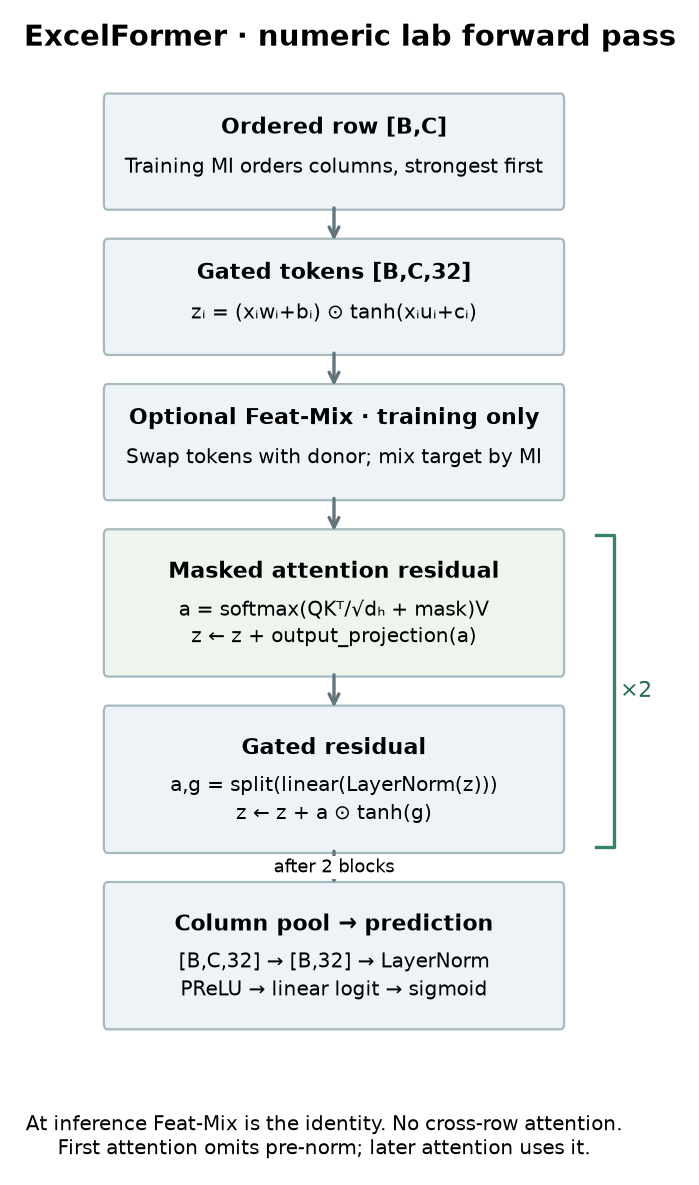

Complete numeric ExcelFormer routing, including training-only mixing and the repeated block.

## 3. Semi-permeable attention: trace the direction




Ordinary attention forms a query Q for each receiver, a key K for each sender, and a value V to transmit. For one head of width dₕ, similarities are QKᵀ/√dₕ. Softmax exponentiates the scores and divides by their sum across senders, giving nonnegative weights that sum to one. Multiplying these weights by V creates one weighted sum per receiver.




A = softmax(QKᵀ / √dₕ + M),   output = AV




**M is a permission mask.** The paper blocks position (i,j) when feature i is more informative than feature j. Row i is the receiver; column j is the sender. The blocked route is therefore **weaker sender → stronger receiver**. With features sorted strongest first, the released implementation allows j≤i, a lower triangle including the diagonal. One broad sentence in the introduction reverses the verbal direction; Eq.2, its adjacent explanation, and the released mask agree on this interpretation. [§3.1, Eq.1–2](https://arxiv.org/html/2301.02819v5#S3.SS1); [pinned released code](https://github.com/WhatAShot/ExcelFormer/blob/17f70526390e70390bb8c8ec3850697eb730f9cd/bin/excel_former.py).




**Mutual information (MI)** measures statistical dependence: how much observing a feature reduces uncertainty about the target. Here it is an estimated, univariate, training-set statistic, not a causal effect or a guarantee of usefulness in interactions. The mask is fixed after fitting the training ordering; attention weights inside allowed positions remain learned and row-dependent. Never estimate this ordering from validation/test labels.




**Predict:** with equal logits and values [2,4,9], what happens to the strongest receiver if the last value doubles? Test your answer below, then remove the mask while keeping the logits fixed.





The masked outputs are [2,3,5]: the first receiver reads only 2, the second averages 2 and 4, and the third averages all three. Changing 9→18 gives [2,3,8]. Without the mask, every output changes from 5→8. These are synthetic arithmetic examples, not learned importance scores. The final model still pools the weak token, so its prediction can change even when the strong token’s attention output cannot.





**Ties require a declared choice.** Eq.2 permits both directions between equal-importance features. The released positional triangle selects one direction even for ties. We reproduce that positional behavior after stable sorting and record it as a paper/code distinction. With noisy MI estimates, a tiny change in ordering can change the allowed graph.





**Interaction-attenuated initialization** starts mixing weights small so the residual path initially dominates. Multiplying a weight’s standard deviation by 0.01 multiplies its variance by 0.0001. The paper describes attenuating SPA broadly; the released code attenuates Q/K/V and the gated update, while its attention output projection has ordinary initialization. The local model follows the released path. Neither small initial weights nor a triangular mask proves eventual generalization superiority.

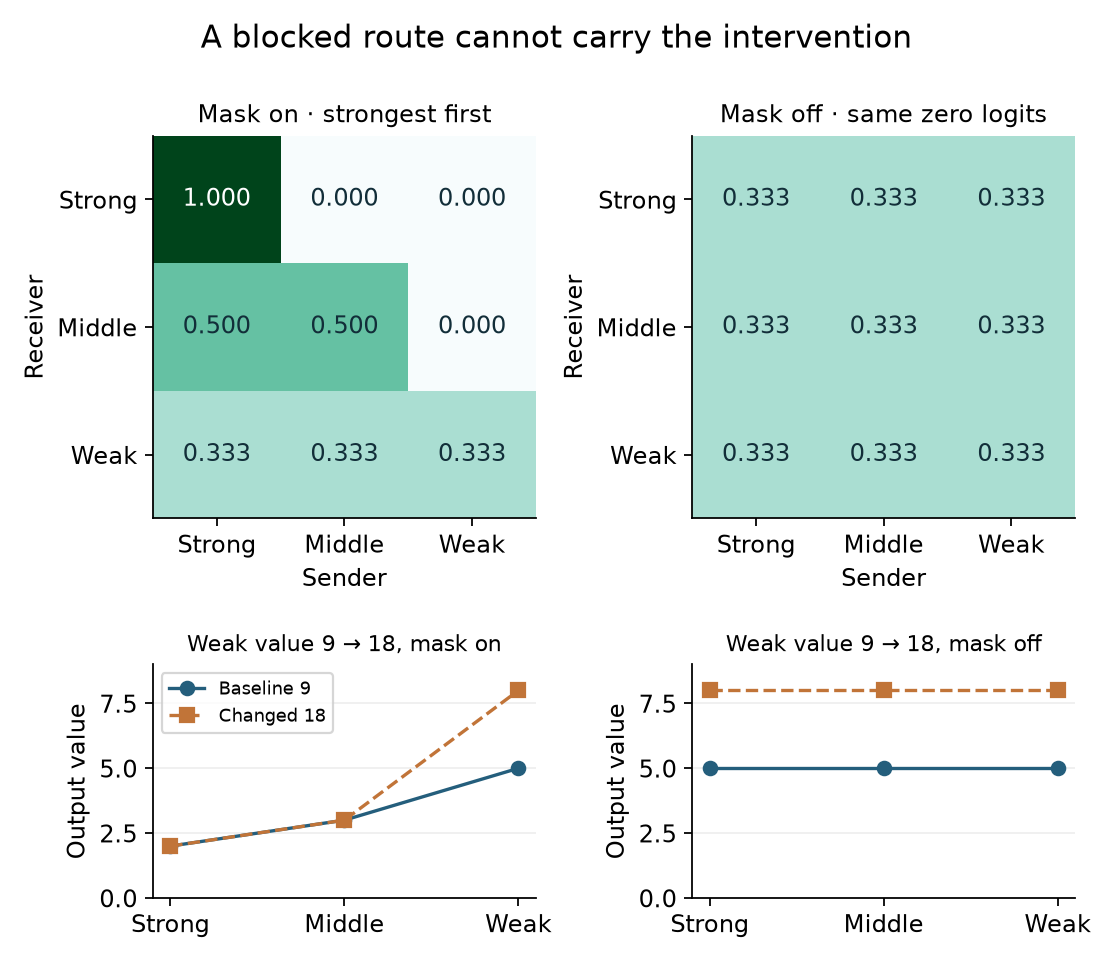

Synthetic intervention: keep equal logits; change weak value 9→18; compare the same receivers with and without masking.

### Task 1 — encode a permission rule
**Why:** a transposed mask can pass every shape check while implementing the opposite model. Inputs have shape [...,C,d_head]. Columns arrive strongest first. Compute scores, block weaker senders, normalize over senders, and return the weighted values plus the pre-dropout attention matrix. Keep dropout behavior provided below.

In [ ]:
# TODO — ExcelFormer Eq.1/2, released positional tie convention.
def spa_attention(q, k, v, dropout=0., training=False):
    scores = ____
    blocked = ____  # boolean [receiver, sender]
    weights = ____
    return F.dropout(weights, dropout, training) @ v, weights

In [ ]:
# CHECK — values, direction, and forbidden gradient pathway.
q=torch.zeros(1,3,2,dtype=torch.double)
v=torch.tensor([[[2.,0.],[4.,0.],[9.,0.]]],dtype=torch.double,requires_grad=True)
z,a=spa_attention(q,q,v)
assert torch.allclose(z[0,:,0],torch.tensor([2.,3.,5.],dtype=torch.double)), 'Inspect sender/receiver orientation.'
assert torch.allclose(a.sum(-1),torch.ones(1,3,dtype=torch.double)), 'Normalize senders, not receivers.'
z[0,0,0].backward()
assert torch.equal(v.grad[0,:,0],torch.tensor([1.,0.,0.],dtype=torch.double)), 'Weak values must have zero path into strong attention output.'
print('CHECK 1 passed: outputs and blocked gradients agree.')

### Read the complete model
These PROVIDED chunks form the model you will train. The block calls **your** `spa_attention`. Tokenization is a featurewise gated map; attention is the only token-mixing operation inside each block. The head subsequently pools all columns, so it can still read a weak feature.

In [ ]:
# PROVIDED — numeric feature embeddings — §3.2
class GatedTokenizer(nn.Module):
    def __init__(self, features, d):
        super().__init__()
        for name in ('weight', 'weight2', 'bias', 'bias2'):
            p = nn.Parameter(torch.empty(features, d))
            nn.init.kaiming_uniform_(p, a=math.sqrt(5))
            setattr(self, name, p)

    def forward(self, x):
        a = x[..., None]*self.weight + self.bias
        b = x[..., None]*self.weight2 + self.bias2
        return a * torch.tanh(b)

In [ ]:
# PROVIDED — attention residual followed by gated residual — released forward path
class SPABlock(nn.Module):
    def __init__(self, d, heads, dropout, scale, first):
        super().__init__()
        assert d % heads == 0
        self.heads, self.dropout = heads, dropout
        self.q, self.k, self.v = [nn.Linear(d, d) for _ in range(3)]
        self.out = nn.Linear(d, d) if heads > 1 else nn.Identity()
        self.gate = nn.Linear(d, 2*d)
        self.norm0 = nn.Identity() if first else nn.LayerNorm(d)
        self.norm1 = nn.LayerNorm(d)
        for layer in (self.q, self.k, self.v, self.gate):
            with torch.no_grad(): layer.weight.mul_(scale)
            nn.init.zeros_(layer.bias)
        if heads > 1: nn.init.zeros_(self.out.bias)

    def forward(self, x):
        b, c, d = x.shape
        z = self.norm0(x)
        q, k, v = [layer(z).reshape(b,c,self.heads,d//self.heads).transpose(1,2)
                   for layer in (self.q,self.k,self.v)]
        update, _ = spa_attention(q,k,v,self.dropout,self.training)
        x = x + self.out(update.transpose(1,2).reshape(b,c,d))
        a, gate = self.gate(self.norm1(x)).chunk(2, dim=-1)
        return x + a * torch.tanh(gate)

In [ ]:
# PROVIDED — complete prediction path; no model package hidden behind this cell
class ExcelFormer(nn.Module):
    """Numeric, pre-norm released variant; logits for binary classification.

    Lab defaults shrink width/depth. Released implementation scales Q/K/V and
    GLU weights; the attention output map uses ordinary Kaiming initialization.
    """
    def __init__(self, features, d=32, heads=4, layers=2, dropout=.1, scale=.01):
        super().__init__()
        self.tokenizer = GatedTokenizer(features,d)
        self.blocks = nn.ModuleList([SPABlock(d,heads,dropout,scale,i==0) for i in range(layers)])
        self.pool = nn.Linear(features,1)
        self.norm = nn.LayerNorm(d)
        self.act = nn.PReLU()
        self.head = nn.Linear(d,1)

    def forward(self,x,mix=None):
        z = self.tokenizer(x)
        if mix is not None: z = mix(z)
        for block in self.blocks: z = block(z)
        z = self.pool(z.transpose(1,2)).squeeze(-1)
        return self.head(self.act(self.norm(z))).squeeze(-1)

In [ ]:
# CHECK — validate your visible model against the canonical implementation.
from relkit.claim_models import ExcelFormer as CanonicalExcel
from relkit.claim_models import spa_attention as canonical_attention

torch.manual_seed(49)
visible=ExcelFormer(5,d=16,heads=2,layers=2,dropout=0).double().eval()
reference=CanonicalExcel(5,d=16,heads=2,layers=2,dropout=0).double().eval()
reference.load_state_dict(visible.state_dict())
x=torch.randn(7,5,dtype=torch.double,requires_grad=True)
xref=x.detach().clone().requires_grad_()
a,b=visible(x),reference(xref)
assert torch.allclose(a,b,atol=1e-10,rtol=1e-10),'Your model differs from the equation-checked canonical path.'
a.sum().backward();b.sum().backward()
assert torch.allclose(x.grad,xref.grad,atol=1e-10,rtol=1e-10),'Input gradient mismatch.'
released=json.loads(Path('_reference_l049_results.json').read_text())
print('Your model matches the canonical path. Separate pinned released-code check:',released)
# The released-code artifact validates canonical code; this cell separately validates your code.

## 4. Feat-Mix: which donor supplies the information?




**Data augmentation** creates modified training examples. Feat-Mix swaps whole feature tokens between two donor rows. Let mᵢ=1 retain feature i from row A and mᵢ=0 take it from B. If Iᵢ is that feature’s nonnegative training MI, the share assigned to A is:




λ = Σᵢ mᵢIᵢ / Σᵢ Iᵢ,   ỹ = λyA + (1−λ)yB




For MI values [6,3,1], keeping only the first feature gives λ=0.6, not 1/3. If donor labels are 1 and 0, the mixed target is 0.6. A **soft target** between zero and one is permitted by binary cross-entropy. It represents a training heuristic; it is not a newly observed outcome. [§4, Eq.7–8](https://arxiv.org/html/2301.02819v5#S4).





Our sampler draws a retention probability from Beta(0.5,0.5), then independent Bernoulli choices per row and feature. Beta here is a distribution over probabilities; its two parameters favor extreme retention shares. This is a documented sampler choice, not a verified match to every detail of the released augmentation code. If total MI is zero, Eq.8 has a zero denominator; the lab explicitly falls back to the retained-feature fraction.




**Hid-Mix**, the paper’s other augmentation, exchanges embedding coordinates across donors, applying the same coordinate mask across feature tokens. Its label interpolation differs from Feat-Mix’s information weighting. We explain the distinction but do not implement or evaluate Hid-Mix today. Do not label our Feat-Mix result as the paper’s “Hid-Mix,” “Mix Tuned,” or “Fully Tuned” result.




Both augmentations are training-only. No donor row or label is needed at inference. This differs from SAINT’s inference-time companion context and from reading a relational neighborhood at prediction time.

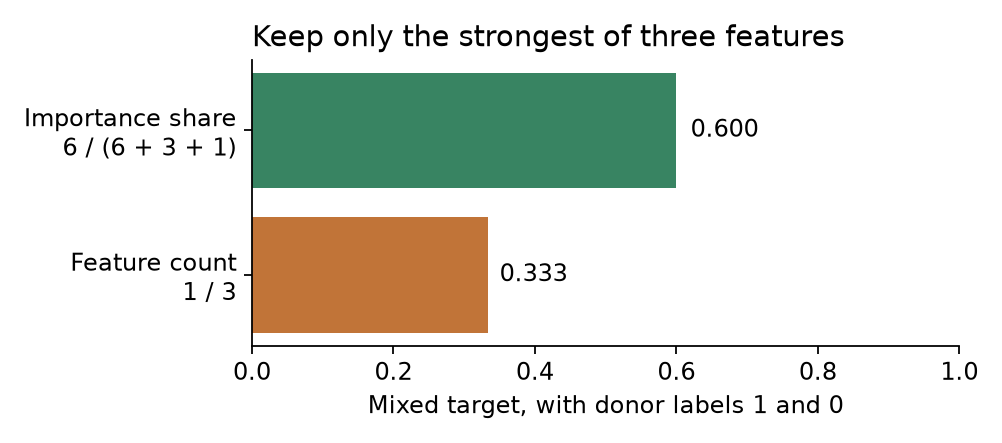

Synthetic donors 1 and 0: retaining feature importance 6 out of 10 gives target 0.600, versus count-based 0.333.

### Task 2 — make the label follow the retained information
**Why:** swapping tensors correctly while mixing labels by the wrong share changes the learning objective. A boolean mask [B,C] chooses donor A. Handle zero total importance explicitly; the fallback is the retained-feature fraction.

In [ ]:
# TODO — ExcelFormer Eq.7/8, plus an explicit zero-information fallback.
def feat_mix(tokens, y, importance, mask, permutation):
    total = importance.sum()
    ratio = ____ if total > 0 else ____
    mixed = ____
    return mixed, ratio*y + (1-ratio)*y[permutation]

In [ ]:
# CHECK — mixed values, targets, all-retained, and zero-information behavior.
tokens=torch.arange(12.).reshape(2,3,2);y=torch.tensor([1.,0.]);imp=torch.tensor([6.,3.,1.]);perm=torch.tensor([1,0])
mask=torch.tensor([[True,False,False],[True,False,False]])
mixed,target=feat_mix(tokens,y,imp,mask,perm)
assert torch.allclose(target,torch.tensor([.6,.4])), 'Weight labels by retained MI.'
assert torch.equal(mixed[:,0],tokens[:,0]) and torch.equal(mixed[:,1:],tokens[perm,1:]), 'Check donor direction.'
_,all_y=feat_mix(tokens,y,imp,torch.ones_like(mask),perm)
assert torch.equal(all_y,y)
_,zero_y=feat_mix(tokens,y,torch.zeros(3),mask,perm)
assert torch.allclose(zero_y,torch.tensor([1/3,2/3])), 'Zero total MI needs a finite declared fallback.'
print('CHECK 2 passed.')

### Read the learning loop
Validation log loss selects the checkpoint. Test labels are never used inside this loop. Feat-Mix runs only in training; prediction applies sigmoid to logits. Small initialized mixing weights are not frozen: optimizer updates can change them.

In [ ]:
# PROVIDED — training, optional Feat-Mix, validation selection, checkpoint restore
def train_excel(model, x, y, train, valid, *, seed=0, epochs=30, lr=.001,
                batch=64, patience=12, augmentation=False, importance=None, device='cpu'):
    """Visible learning loop: select checkpoint using validation log loss only."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model = model.to(device)
    xt = torch.as_tensor(x,dtype=torch.float32,device=device)
    yt = torch.as_tensor(y,dtype=torch.float32,device=device)
    imp = torch.as_tensor(importance,dtype=torch.float32,device=device) if importance is not None else None
    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=0)
    best, best_state, stale, history = float('inf'), None, 0, []
    for epoch in range(epochs):
        model.train()
        for ids in np.array_split(rng.permutation(train), max(1,math.ceil(len(train)/batch))):
            target = yt[ids]
            mix = None
            if augmentation:
                keep = rng.beta(.5,.5)
                mask = torch.rand((len(ids),x.shape[1]),device=device) < keep
                perm = torch.randperm(len(ids),device=device)
                # Compute targets via the SAME primitive that mixes embeddings.
                _, target = feat_mix(xt[ids,...,None],target,imp,mask,perm)
                mix = lambda z: feat_mix(z,yt[ids],imp,mask,perm)[0]
            logits = model(xt[ids],mix=mix)
            loss = F.binary_cross_entropy_with_logits(logits,target)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            score = float(F.binary_cross_entropy_with_logits(model(xt[valid]),yt[valid]))
        history.append({'epoch':epoch+1,'valid_log_loss':score})
        if score < best:
            best,best_state,stale = score,copy.deepcopy(model.state_dict()),0
        else: stale += 1
        if stale >= patience: break
    model.load_state_dict(best_state)
    model.eval()
    return model,history

In [ ]:
# PROVIDED — batched, independent-row inference
@torch.no_grad()
def predict_excel(model,x,batch=1024):
    device = next(model.parameters()).device
    return np.concatenate([torch.sigmoid(model(torch.as_tensor(a,dtype=torch.float32,device=device))).cpu().numpy()
                           for a in np.array_split(x,max(1,math.ceil(len(x)/batch)))])

## 5. Model architecture — Trompt




Trompt uses learned **column embeddings** to represent table structure and learned **prompt embeddings** to query that structure. These are trainable vectors, not text instructions. There is no pretrained language model in this architecture. Both embedding sets are shared across input rows; dependence on an individual row enters through the previous cell’s representation. [§3](https://arxiv.org/html/2305.18446v2#S3).





A cell fuses the broadcast prompt Eₚ with the preceding output Oprev:




H = dense(concat(Eₚ, Oprev)) + Eₚ + Oprev  
M = softmax(H Ecolumnᵀ)   [B,P,C]




Concatenation puts two d-wide vectors side by side; the dense map reduces 2d back to d. Each prompt then scores every column. Softmax runs over **C, the column axis**, so each prompt gets its own distribution over columns. The paper’s Eq.4 does not divide these scores by √d; importing that factor from Transformer attention would change the specified operation. The weights can be row-specific because H can be row-specific, even though Ecolumn is shared.




Feature values take a separate route: numeric dense maps or category lookups produce Efeature [B,C,d], and a learned expansion provides a prompt axis, giving Ê [B,P,C,d]. The full paper cell includes normalization and residual machinery on this path. We do not silently replace it with a broadcast and call that a complete Trompt implementation.




O[b,p,k] = Σc M[b,p,c] × Ê[b,p,c,k]   → [B,P,d]




Indices b,p,c,k identify a row, prompt, column and embedding coordinate. The sum removes the column axis. It preserves the prompt axis, letting different prompts retain different summaries. These are the two live implementation exercises: compute M correctly, then sum the weighted expanded features over the correct axis. [§3.1, Eq.1–5](https://arxiv.org/html/2305.18446v2#S3.SS1).





In this worked example, column vectors are [1,0], [0,1], [0,0] and one fused query is [t,0]. At t=0 the weights are uniform and the output from values [2,4,9] is 5. At t=2 the logits are [2,0,0], the weights are approximately [0.787,0.107,0.107], and the output is 2.959. Numbers displayed to three decimals are rounded; computations use full precision.




**First-cell subtlety:** if Oprev starts identically for all rows, the initial weights are identical across rows. Values still differ, so the first output can differ; later fusion can then produce row-specific weights. The notebook deliberately uses a shared zero initial state to test this conditional statement. That test is not evidence of the full released initialization or architecture.




The downstream head uses another softmax, this time over **P, the prompt axis**, to combine prompt representations. Two dense layers with ReLU produce class scores. The same downstream module serves multiple cells. Training sums the individual cell losses; inference averages cell predictions in Eq.9. Our untrained routing probe never substitutes for this complete training scheme. [§3.2](https://arxiv.org/html/2305.18446v2#S3.SS2).

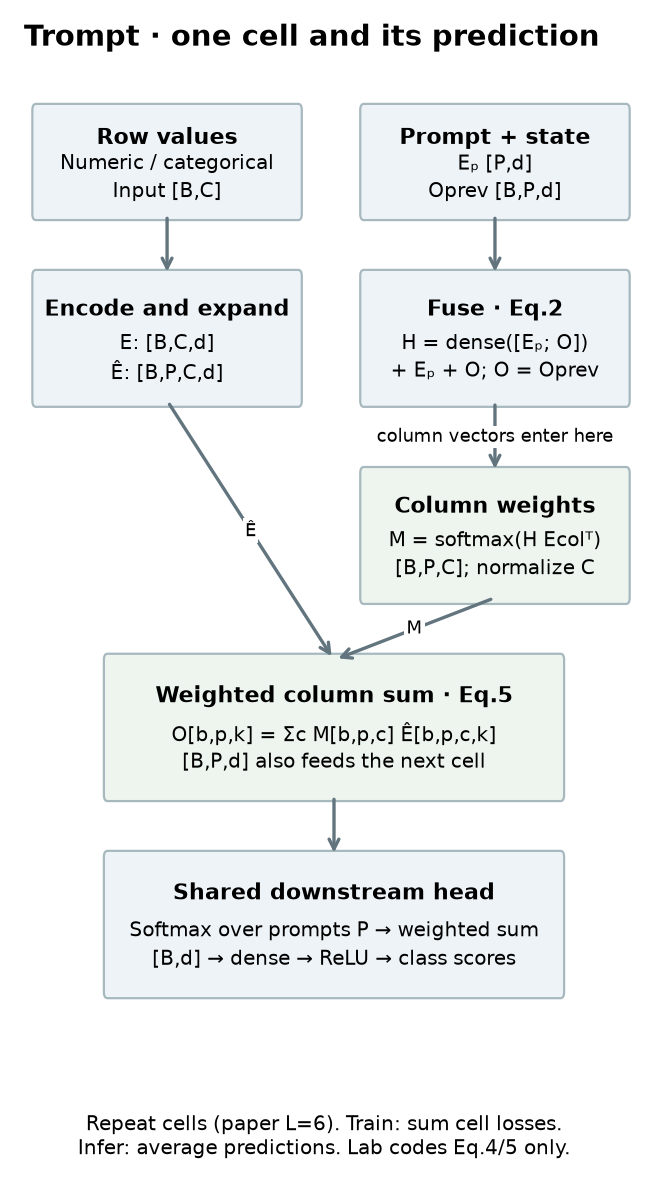

Full Trompt paper routing. The notebook implements Eq.4/5; other modules remain unimplemented and untrained here.

![Synthetic one-prompt example: fixed column vectors and values, query changes [0,0]→[2,0]; output changes 5.000→2.959.](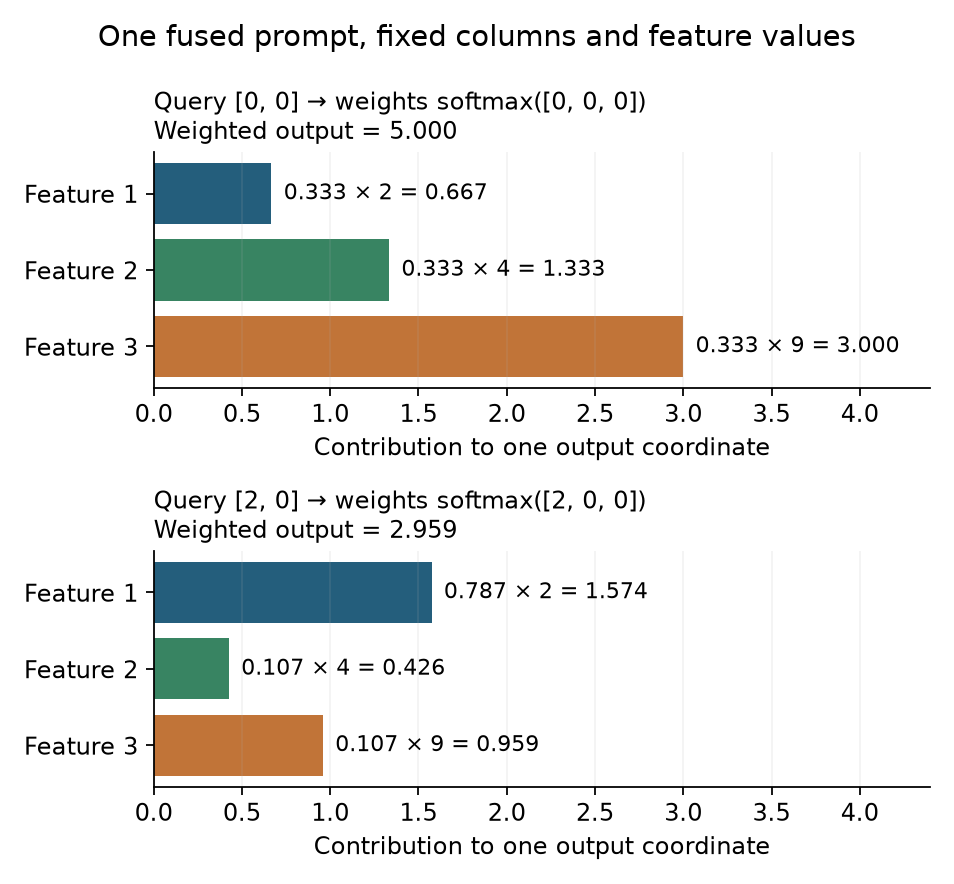)

Synthetic one-prompt example: fixed column vectors and values, query changes [0,0]→[2,0]; output changes 5.000→2.959.

### Task 3 — preserve the right axes
**Why:** mixing up columns and prompts yields plausible shapes in symmetric examples. Use unequal P and C in the checks. Implement Eq.4 with unscaled dot products, then Eq.5 on already-expanded features. The expansion tensor below is PROVIDED test data, not a replacement for the full paper’s learned expansion.

In [ ]:
# TODO — Trompt Eq.4 and Eq.5.
def prompt_weights(fused_prompts, columns):
    return ____

def prompt_reduce(weights, expanded_features):
    return ____

In [ ]:
# CHECK — non-square axes and controlled row-specificity.
columns=torch.tensor([[1.,0.],[0.,1.],[0.,0.]])
shared=torch.zeros(2,2,2)  # B=2, P=2, d=2; same initial fused query
w=prompt_weights(shared,columns)
assert w.shape==(2,2,3) and torch.allclose(w.sum(-1),torch.ones(2,2))
assert torch.equal(w[0],w[1]), 'Identical fused queries must produce identical weights.'
changed=shared.clone();changed[1,0,0]=2
wc=prompt_weights(changed,columns)
assert torch.allclose(wc[1,0],torch.tensor([.786986,.106507,.106507]),atol=1e-6), 'Eq.4 has no sqrt(d) divisor.'
values=torch.tensor([2.,4.,9.]).reshape(1,1,3,1).expand(2,2,3,2)
z=prompt_reduce(wc,values)
assert z.shape==(2,2,2), 'Sum columns C; preserve prompts P and coordinates d.'
assert abs(z[0,0,0].item()-5)<1e-6 and abs(z[1,0,0].item()-2.958563)<1e-5
assert torch.equal(z[0],prompt_reduce(wc[:1],values[:1])[0]), 'No cross-row information route.'
print('CHECK 3 passed. Changed query reweights columns without any other batch row.')

## 6. Audit the protocol before comparing the numbers




A **protocol** specifies which information is available, how data are partitioned, how settings are chosen, and how performance is measured. A comparison is meaningful only relative to that protocol. Record the following before training:






| Question | ExcelFormer v5 | Trompt v2 |
| --- | --- | --- |
| Which population? | 96 small and 21 larger tabular datasets. | Grinsztajn45 with medium/large and numeric/heterogeneous groups; additional suites in appendices. |
| Which partition? | Random 80/20 outer split; 20% of the training portion reserved for validation: 64/16/20 overall. | Benchmark prepared IID data; its stated scope does not establish future-time transfer. |
| Which selection budget? | Default, augmentation-tuned, and fully tuned variants are distinct. Tree tuning expands to 500 trials; do not dismiss the baseline as untuned. | 40 effective Trompt combinations. Results are duplicated to avoid truncating other models’ benchmark search traces. |
| Which metric? | AUROC for binary classification, accuracy for multiclass, negative RMSE for regression; ranks aggregate tasks. | Accuracy and R², with benchmark normalization/search curves. |
| What does this permit? | A claim about these tasks, model variants and budgets. | A scoped comparability claim with subgroup exceptions. |






Primary audit reading: [ExcelFormer §6.1](https://arxiv.org/html/2301.02819v5#S6.SS1), [Trompt Appendix A](https://arxiv.org/html/2305.18446v2#A1), and [Trompt Appendix F](https://arxiv.org/html/2305.18446v2#A6). Read these before the headline results.




**Unique configurations are not plotted entries.** Repeating results from 40 evaluated settings does not create 300 independent model fits or 300 new settings. That observation is an accounting distinction, not proof of misconduct or invalid scores. Ask what each x-axis unit counts and what selection happened before it was plotted. Equal trial counts also need not mean equal compute: model sizes, epochs, early stopping and parallel hardware differ.




**Dataset names are not independence guarantees.** ExcelFormer’s appendix contains several diabetes and similarly named dataset entries. Similar names alone do not prove duplicate rows. An audit should compare provenance and row fingerprints before treating each entry as independent evidence. Our local rank summary uses three distinct tasks, including just one Pima variant.




**Metric identity matters.** AUROC measures positive-vs-negative score ordering, counting tied pairs as half. Accuracy measures the fraction of correct thresholded labels. Log loss measures probability quality and penalizes confident mistakes. A higher AUROC can coexist with lower accuracy. We select neural checkpoints by validation log loss, report test AUROC and log loss, and do not cherry-pick the test metric afterward.

## 7. The experiment we actually ran




**Held fixed:** the authors’ released Pima-Indians-Diabetes, Breast Cancer Dataset, and Swiss-banknote-conterfeit-detection splits; prepared numeric values; model seeds 0/1/2; and per-task evaluation rows. Files are checked by SHA-256, a content fingerprint. MI ordering uses training labels only. We do not reconstruct or independently certify the upstream preparation that created those downloaded arrays.




**Varied:** numeric ExcelFormer without augmentation, the same model with our Feat-Mix sampler, and a CatBoost comparator. Each neural arm uses d=32, four heads, two blocks, dropout 0.1, AdamW at 0.001 with no weight decay, batches of 64, at most 30 epochs, and validation patience 12. CatBoost uses at most 300 trees, depth 6 and learning rate 0.05, selecting by validation log loss. These are fixed local budgets, not equal wall-clock budgets or the paper’s tuning search.








| Task | Excel · no DA | Excel · Feat-Mix | CatBoost |
| --- | --- | --- | --- |
| pima | 0.8191 ± 0.0041 | 0.8195 ± 0.0111 | 0.8175 ± 0.0012 |
| breast | 0.9969 ± 0.0017 | 0.9960 ± 0.0027 | 0.9968 ± 0.0013 |
| banknote | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 | 1.0000 ± 0.0000 |





Mean ranks: Excel no DA 1.667; Feat-Mix 2.000; CatBoost 2.333. Friedman p=0.607; Nemenyi critical difference=1.914. This three-task experiment detects no overall difference. Banknote has AUROC 1.0 for all arms on this small test split; that is saturation, not proof of perfect future predictions. The breast task also has very little headroom.





The error bars show **sample standard deviation across three model seeds**, not confidence intervals over future populations. The JSON also reports 95% t intervals for the seed mean, conditional on one fixed split. A **rank** orders models within each task, avoiding averaging metrics with incompatible scales. We average task ranks and calculate a Friedman rank test plus the Nemenyi critical difference; with only three datasets, this is a low-power descriptive exercise. Failure to detect a difference does not establish equivalence.




Reproducibility files: [scores, predictions, histories, environment and split indices](../labs/_verify_l049_results.json); [released forward/gradient check](../labs/_reference_l049_results.json). With copied weights, our specified ExcelFormer path matches the pinned released implementation exactly in double precision, including input gradients. The reference executes the released model classes with a small adapter supplying their tanh-gated activation; we do not install the full original training environment. This verifies the numeric pre-normalization, no-compression evaluation path; it does not establish augmentation, optimizer, categorical or all-variant parity.

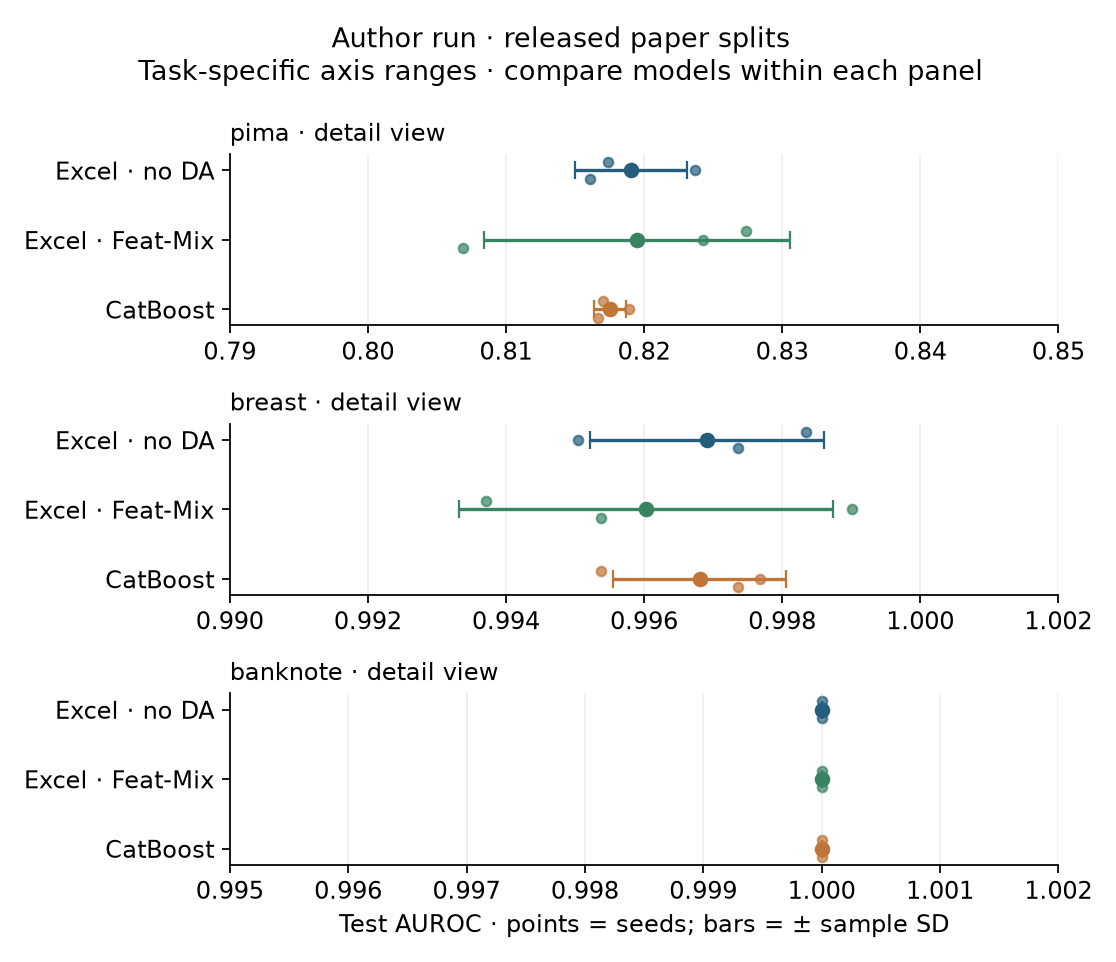

Author-reference test AUROC on three released tasks; seed points and ± sample SD. These are not current kernel outputs.

### PROVIDED — inspect data provenance before training
The authors’ already-prepared arrays are deliberately used unchanged. Their upstream preprocessing fit scope is not independently reconstructed. We fit only the new MI order on training rows. Checksums detect changed downloaded data; they do not prove absence of upstream leakage.

In [ ]:
data=paper_data('pima')
print({k:len(data[k]) for k in ('train','valid','test')})
print('Columns in model order:',[data['meta']['columns'][i] for i in data['meta']['order']])
display(pd.DataFrame(data['x'][:5]))
assert not (set(data['train']) & set(data['test']))
assert data['importance'].tolist()==sorted(data['importance'].tolist(),reverse=True)
print('Declared source:',data['meta']['source'])

### PROVIDED — the comparison harness is visible too
It trains the model defined above. CatBoost is a library baseline; it is not the architecture being taught. The same split is held across arms; these different model families receive explicit fixed budgets, not equal compute or a paper-level search.

In [ ]:
ARMS=('excel_no_da','excel_feat_mix','catboost')
def experiment(data,seeds=(0,1,2),epochs=30,d=32,layers=2,heads=4,lr=.001,batch=64,
               patience=12,dropout=.1,trees=300,device='cpu',model_cls=ExcelFormer,
               train_fn=train_excel,predict_fn=predict_excel,artifact_dir=None):
    torch.set_num_threads(1)
    x,y,tr,va,te=[data[k] for k in ('x','y','train','valid','test')]
    rows,losses,diagnostics=[],[],{}
    if artifact_dir is not None:
        artifact_dir=Path(artifact_dir);artifact_dir.mkdir(parents=True,exist_ok=True)
    for seed in seeds:
        auc,logs={},{}
        for arm in ARMS:
            if arm=='catboost':
                model=CatBoostClassifier(iterations=trees,depth=6,learning_rate=.05,random_seed=seed,
                    thread_count=1,verbose=False,allow_writing_files=False,eval_metric='Logloss')
                model.fit(x[tr],y[tr],eval_set=(x[va],y[va]),use_best_model=True)
                p=model.predict_proba(x[te])[:,1]
                diagnostics[f'{seed}/{arm}']={'selected_trees':int(model.tree_count_)}
                if artifact_dir is not None: model.save_model(str(artifact_dir/f'{seed}-{arm}.cbm'))
            else:
                torch.manual_seed(seed)
                model=model_cls(x.shape[1],d=d,layers=layers,heads=heads,dropout=dropout)
                model,hist=train_fn(model,x,y,tr,va,seed=seed,epochs=epochs,lr=lr,batch=batch,
                    patience=patience,augmentation=arm=='excel_feat_mix',importance=data['importance'],device=device)
                p=predict_fn(model,x[te])
                diagnostics[f'{seed}/{arm}']={'history':hist,'parameters':sum(p.numel() for p in model.parameters())}
                if artifact_dir is not None: torch.save(model.state_dict(),artifact_dir/f'{seed}-{arm}.pt')
            auc[arm]=float(roc_auc_score(y[te],p));logs[arm]=float(log_loss(y[te],p,labels=[0,1]))
            diagnostics[f'{seed}/{arm}']['test_probabilities']=p.tolist()
        rows.append(auc);losses.append(logs)
    return {'auroc':rows,'log_loss':losses,'diagnostics':diagnostics,'protocol':data['meta']}

In [ ]:
# CHECK — prove that training reaches your function, not a packaged replacement.
original_spa=spa_attention
calls={'count':0}
def counted_spa(*args,**kwargs):
    calls['count']+=1
    return original_spa(*args,**kwargs)
spa_attention=counted_spa
try:
    torch.manual_seed(0)
    smoke=ExcelFormer(data['x'].shape[1],d=16,heads=2,layers=1,dropout=0)
    smoke,_=train_excel(smoke,data['x'],data['y'],data['train'],data['valid'],epochs=1)
finally:
    spa_attention=original_spa
assert calls['count']>0,'Training bypassed your attention implementation.'
print('Live student attention calls:',calls['count'])

### Run the three-task experiment
Before execution, predict where augmentation may help and why the tiniest test set may saturate. Changing that prediction after seeing the scores is not evidence of foresight. Seeds measure initialization/training variability on fixed splits, not population uncertainty.

In [ ]:
# PROVIDED — measured outputs from YOUR current code.
local={}
for name in ('pima','breast','banknote'):
    local[name]=experiment(paper_data(name),model_cls=ExcelFormer,train_fn=train_excel,predict_fn=predict_excel)
    print('Finished',name)
summary=summarize({k:v['auroc'] for k,v in local.items()},ARMS)
def summary_table(summary):
    return pd.DataFrame({ds:{m:f"{v['mean']:.4f} ± {v['sample_std']:.4f}" for m,v in models.items()}
                         for ds,models in summary['per_dataset'].items()}).T
display(summary_table(summary))
print('Mean ranks:',summary['mean_ranks'],'Friedman:',summary.get('friedman'),'CD:',summary.get('nemenyi_cd'))

In [ ]:
# CHECK — local reproducibility against author evidence on this software environment.
author=json.loads(Path('_verify_l049_results.json').read_text())
same_versions=environment()['versions']==author['environment']['versions']
max_score_change=max(abs(summary['per_dataset'][ds][m]['mean']-author['summary']['per_dataset'][ds][m]['mean']) for ds in local for m in ARMS)
print('Same recorded versions:',same_versions,'max mean AUROC change:',max_score_change)
if same_versions:
    assert max_score_change<1e-6,'Inspect student code / protocol before interpreting changed rankings.'
# Different package versions may produce different scores; document them, do not overwrite the ledger.
print('CHECK 4: evidence computed; compare full protocol, not one rounded score.')

## 8. Change the deployment question: predict later events




A random split asks about another observation mixed with the observed period. A **temporal split** trains on earlier observations, selects settings on a later validation interval, and evaluates on the latest interval. It changes the target population and often entity coverage. It is not just a more difficult version of the identical statistical question.




Our separate transfer probe reuses the real MovieLens-1M timestamps from L048. Remove rating 3; labels are zero for 1–2 and one for 4–5. Sample 12,000 events without consulting their labels using seed 49. The random regime uses stratified 64/16/20 splits with seed 49. The temporal regime assigns whole timestamp groups around the 64% and 80% time quantiles, so no timestamp straddles a boundary.




Inputs are age and training-only category frequencies for user, movie, gender, occupation and ZIP. A frequency is the share of training events with that category; unseen categories map to zero. Quantile transformation and MI ordering fit only the corresponding training partition. Category IDs are never treated as measured magnitudes. Ratings and timestamps are excluded from inputs. We use the dataset’s demographic snapshot; its exact historical availability is not verified, so this is a time-transfer demonstration, not a certified production point-in-time dataset.




Frequency encoding deliberately loses category identity and is not the paper’s target encoder. Both regimes use the same events, model budgets and feature-building rule, but fit their transforms independently on the proper training rows. Their test sets differ. A score change therefore combines distribution, composition, representation and fitted-model effects; it is not a paired causal estimate of “the effect of time.”







| Task | Excel · no DA | Excel · Feat-Mix | CatBoost |
| --- | --- | --- | --- |
| random | 0.6751 ± 0.0040 | 0.6708 ± 0.0020 | 0.6862 ± 0.0029 |
| temporal | 0.6755 ± 0.0022 | 0.6750 ± 0.0028 | 0.6692 ± 0.0012 |





Here CatBoost leads under random splitting, while the neural arms lead on the later interval. This is a measured ranking reversal for our fixed pipeline, not a universal temporal advantage. Excel no DA barely changes in mean AUROC; a temporal split does not mechanically lower every model’s score.





Do not add random and temporal MovieLens as two independent datasets to the three-task Friedman analysis. They share an underlying source. A result here says something about our transferred pipeline; it cannot refute or reproduce either paper’s original benchmark.

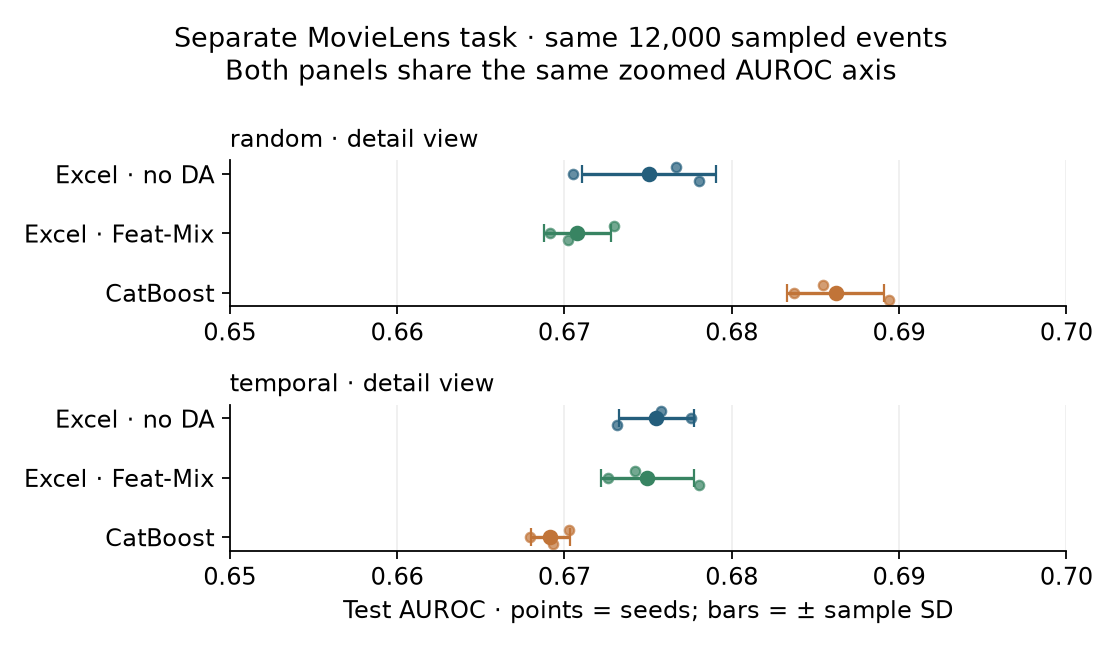

Author-reference MovieLens transfer results; random and chronological test populations differ. These are not two independent benchmark datasets.

In [ ]:
# PROVIDED — replay time transfer with the same live implementation.
transfer={}
for kind in ('random','temporal'):
    frame=temporal_data(kind)
    ranges=frame['meta']['timestamp_ranges']
    if kind=='temporal':
        assert ranges['train'][1]<ranges['valid'][0]<ranges['test'][0], 'Timestamp groups crossed partitions.'
    transfer[kind]=experiment(frame,model_cls=ExcelFormer,train_fn=train_excel,predict_fn=predict_excel)
    print(kind,ranges)
transfer_summary=summarize({k:v['auroc'] for k,v in transfer.items()},ARMS)
display(summary_table(transfer_summary))
assert transfer['random']['protocol']['row_ids']==transfer['temporal']['protocol']['row_ids']
print('Same sampled events. Different test populations: do not call the score difference a paired causal effect.')

### EXIT — write a claim audit
Fill the four fields below using your evidence. The automatic check can verify that you supplied an answer; it cannot grade your reasoning. Paste the printed ticket to your teacher for feedback. A loss or INCOMPARABLE verdict is acceptable; inventing a replicated claim is not.

In [ ]:
# TODO — your written audit; retain the dictionary keys.
audit = {
    'paper_claim': '____',
    'local_scope': '____',
    'temporal_limit': '____',
    'reproduction_verdict': '____',
}

In [ ]:
# CHECK / EXIT — content is reviewed by the teacher, not automatically scored.
assert all(isinstance(v,str) and '____' not in v and len(v.split())>=8 for v in audit.values()), 'Supply your own supported explanations.'
ticket={'lesson':49,'audit':audit,'local_summary':summary,'transfer_summary':transfer_summary,
        'environment':environment(),'full_trompt_benchmark':'NOT_RUN'}
Path('data/cache/l049-exit.json').write_text(json.dumps(ticket,indent=2))
print(json.dumps(ticket,indent=2))

## 9. Move closer to the paper, then keep the ledger honest




The next step uses the *same visible implementation*, the authors’ Pima split, d=256, 32 heads, three blocks, dropout 0.3 and learning rate 0.0001. The closer preset caps training at 100 epochs with patience 32, uses batches of 256, and allows 1,000 CatBoost trees. The longer `paper` preset raises the caps to 1,000 epochs and 4,096 trees; its name describes a capacity/budget option, not completed paper replication. Neither runs the paper’s tuning search.




The specific cited target is the appendix row **Pima-Indians-Diabetes**: Feat-Mix default AUROC 0.8356 and tuned CatBoost 0.7528. Other similarly named Pima rows have different scores. These are the authors’ reported five-run results, not our outputs. [ExcelFormer Appendix G](https://arxiv.org/html/2301.02819v5#A7).







| Task | Excel · no DA | Excel · Feat-Mix | CatBoost |
| --- | --- | --- | --- |
| pima | 0.8383 ± 0.0099 | 0.8261 ± 0.0057 | 0.8175 ± 0.0012 |





**Larger-run verdict: INCOMPARABLE.** Width, depth and attention heads align more closely with the paper, but a single released split, chosen epoch cap and batch size, augmentation sampling details and absent hyperparameter search prevent an exact table reproduction. Selected weights, predictions and histories are saved under `labs/data/cache/l049-closer/`; regenerate them with the runner.





**Conclusion ledger:** verified here = specified forward path, equation probes, and measured local runs; paper claim = cited benchmark results; scale-up = the larger Pima attempt with its own configuration and artifacts. A close score with a different protocol remains **INCOMPARABLE** as an exact reproduction. It may be numerically close; that is a different sentence.




The lab includes a gated Colab next step and [a Modal T4 operator](../modal/l049_paper_repro.py). Both use the same runner, save selected weights and predictions, resume completed seeds, and reject incompatible cached runs. The 96/21-task ExcelFormer suite, its tuning search, and the full Trompt benchmark remain **NOT_RUN**.

### NEXT STEP — run closer to the paper
The loop below reuses the same model and training functions you just read. Set the gate to True on a suitable runtime. `smoke` verifies the operator quickly; `closer` uses width 256 / 3 blocks / 32 heads on Pima; `paper` increases caps but still does not run the published suite or tuning search. Keep those gaps in the verdict.

The output directory stores a contract, per-seed results, predictions and selected weights. Use a fresh directory after implementation or protocol changes. For unattended GPU execution: `modal run --detach modal/l049_paper_repro.py --preset closer` from the repository root. No cloud job has been launched by authoring this lesson.

In [ ]:
# PROVIDED — explicit presets
PRESETS={
    'smoke':dict(epochs=2,d=16,layers=1,heads=2,lr=.001,batch=256,patience=2,dropout=.1,trees=20),
    'closer':dict(epochs=100,d=256,layers=3,heads=32,lr=.0001,batch=256,patience=32,dropout=.3,trees=1000),
    'paper':dict(epochs=1000,d=256,layers=3,heads=32,lr=.0001,batch=256,patience=32,dropout=.3,trees=4096)}

In [ ]:
# PROVIDED — resumable closer-to-paper runner
def run(preset='closer',out='data/cache/l049-closer',device=None,model_cls=ExcelFormer,
        train_fn=train_excel,predict_fn=predict_excel,attention_fn=spa_attention,mix_fn=feat_mix):
    """Resume only identical source/config/data/device runs. Keep the student's code live."""
    cfg=PRESETS[preset];folder=Path(out);folder.mkdir(parents=True,exist_ok=True)
    data=paper_data('pima');device=device or ('cuda' if torch.cuda.is_available() else 'cpu')
    # In notebooks inspect.getsource can fail. Hash bytecode plus source where available.
    identities=[]
    dependencies=model_cls.__init__.__globals__
    for obj in (model_cls,dependencies['GatedTokenizer'],dependencies['SPABlock'],
                train_fn,predict_fn,attention_fn,mix_fn):
        try: identities.append(inspect.getsource(obj))
        except (OSError,TypeError):
            import marshal
            funcs=[obj.__init__,obj.forward] if inspect.isclass(obj) else [obj]
            identities.extend(marshal.dumps(f.__code__).hex() for f in funcs)
    contract={'preset':preset,'config':cfg,'data':data['meta'],'environment':environment(),
              'device':device,'implementation':identities}
    digest=hashlib.sha256(json.dumps(contract,sort_keys=True).encode()).hexdigest()
    contract_path=folder/'contract.json'
    if contract_path.exists():
        assert json.loads(contract_path.read_text())['digest']==digest,'Changed implementation/protocol: choose a fresh output folder.'
    else: contract_path.write_text(json.dumps({'digest':digest,'contract':contract},indent=2))
    rows=[];seeds=(0,) if preset=='smoke' else (0,1,2)
    for seed in seeds:
        path=folder/f'seed-{seed}.json'
        if path.exists(): r=json.loads(path.read_text())
        else:
            r=experiment(data,seeds=(seed,),device=device,model_cls=model_cls,train_fn=train_fn,predict_fn=predict_fn,
                         artifact_dir=folder/'weights',**cfg)
            path.write_text(json.dumps(r,indent=2))
        rows.extend(r['auroc'])
        print('completed seed',seed,flush=True)
    result={'preset':preset,'summary':summarize({'pima':rows},ARMS),'contract_sha256':digest,
            'environment':environment(),'paper_target':{'table':'ExcelFormer v5 Table 14, Pima-Indians-Diabetes','feat_mix_auroc':.8356,'catboost_tuned_auroc':.7528},
            'verdict':'INCOMPARABLE','gaps':['One released split versus published five-run mean.',
            'Chosen batch size/epoch cap; no paper hyperparameter search.',
            'Our per-row Bernoulli Feat-Mix sampler is a documented implementation choice; source augmentation parity not established.',
            'Published upstream preprocessing fit scope is not reconstructed.',
            'Single dataset; the 96/21-table suites and full Trompt benchmark remain NOT_RUN.']}
    (folder/'summary.json').write_text(json.dumps(result,indent=2))
    return result

In [ ]:
# NEXT STEP — gated OFF until you choose a runtime and output directory.
RUN_PAPER_REPRO = False
PAPER_PRESET = 'closer'
PAPER_OUT = 'data/cache/l049-student-closer'
if RUN_PAPER_REPRO:
    paper_result=run(PAPER_PRESET,PAPER_OUT,model_cls=ExcelFormer,train_fn=train_excel,
                     predict_fn=predict_excel,attention_fn=spa_attention,mix_fn=feat_mix)
    display(summary_table(paper_result['summary']))
    print(paper_result['verdict'],paper_result['gaps'])
else:
    print('Current student scale-up: NOT_RUN. Author larger run is a separate snapshot.')

**Ask a follow-up.** Explain any unclear arrow, tensor axis, source discrepancy, seed interval or claim boundary. Bring your EXIT ticket; completion alone does not establish mastery of every introduced term. Next lesson is the Q1 fair-comparison checkpoint.